In [13]:
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [14]:
phi = var(r'φ') # scalar field
lam = var(r'λ') 
k = 1
lam =1
V0 = var(r'V_0')
N = var('N')
Q = var('Q') # coupling variable

# Expression for V
def V(V0,phi):
    return V0*exp(-lam*k*phi)

def dVdphi(V0,phi):
    return -lam*k*V(V0,phi)

In [15]:
ohm_m = 0.3
Ho = 6.1324e-61 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho^2/(k^2)) # current critical energy density
V_value = rho_c0*1e11 #
#V_value = rho_c0
Q = 0
gam = 1
Ni = 0
show(V_value)

1.12818989280000e-109

In [16]:
def CoupledCopelandKG(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Vfunc = V(V_value,X[0])
    #Vfunc = V.subs(V0 == V_value,phi ==X[0])
    dVfunc = dVdphi(V_value,X[0])
    #dVfunc = dvdΦ.subs(V0 == V_value,Phi ==X[0])
    H2 = (rho_m + Vfunc)/(3-.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2 - Q*rho_m/H2
    return [x1prime,x2prime]

In [17]:
show(CoupledCopelandKG([1,0],Ni))

[0,
 (1.12818989280000e-109)*e^(-1)/((3.76063297600000e-110)*e^(-1) + 1.12818989280000e-121)]

-10.0

1.12818989280000e-109

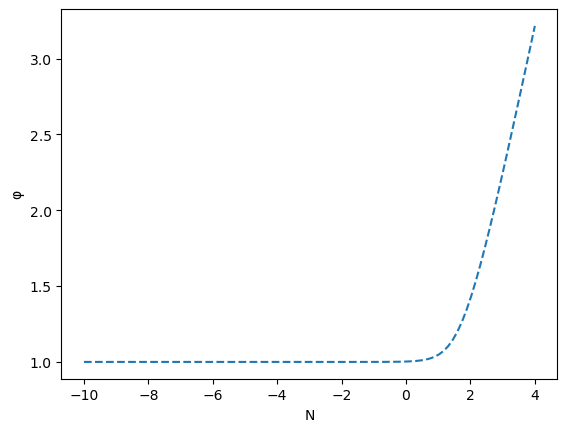

In [18]:
Nrange = np.linspace(-10,4,100)
Ni = Nrange[0]
show(Ni)
sol = odeint(CoupledCopelandKG,[1,0],t=Nrange)
show(V_value)
# Plot of φ against redshift
phi_sol = sol[:,0]
phi_prime = sol[:,1]

z_values = exp(-Nrange)
plt.xlabel("N")
plt.ylabel(r"φ")
plt.plot(Nrange,(phi_sol),'--')

In [19]:
# Multiple Values of Q
def other_parameters(fi,dfi,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3) #1e7 is that initial pmi value
    Pot = V(V_value,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + Pot #Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ #Equation of State wΦ
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m

In [20]:
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(phi_sol,phi_prime,Nrange)
Z = z+1
#show(rho_m)

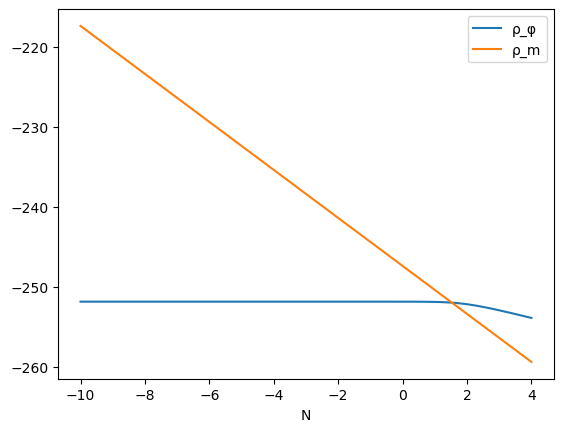

In [21]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs N

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"ρ_φ")
plt.plot(Nrange,log(rho_m),label=r"ρ_m")
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
plt.legend()

0.9959158249086354

0.3279610174407395

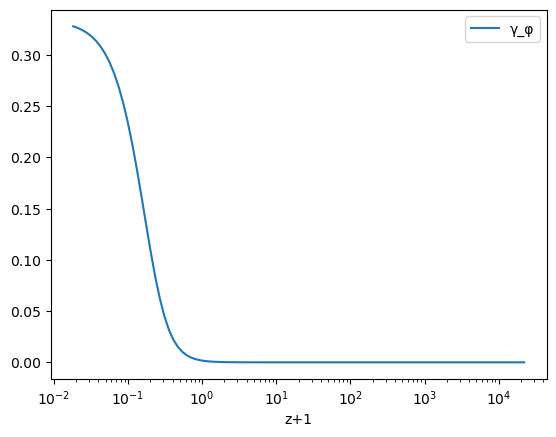

In [22]:
# Plots of φ,φ',ωφ,ρφ,Ωφ vs z+1

#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
#plt.plot(Z,log(rho_s),label=r"ρ_φ")
#plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
show(max(O_Q))
show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

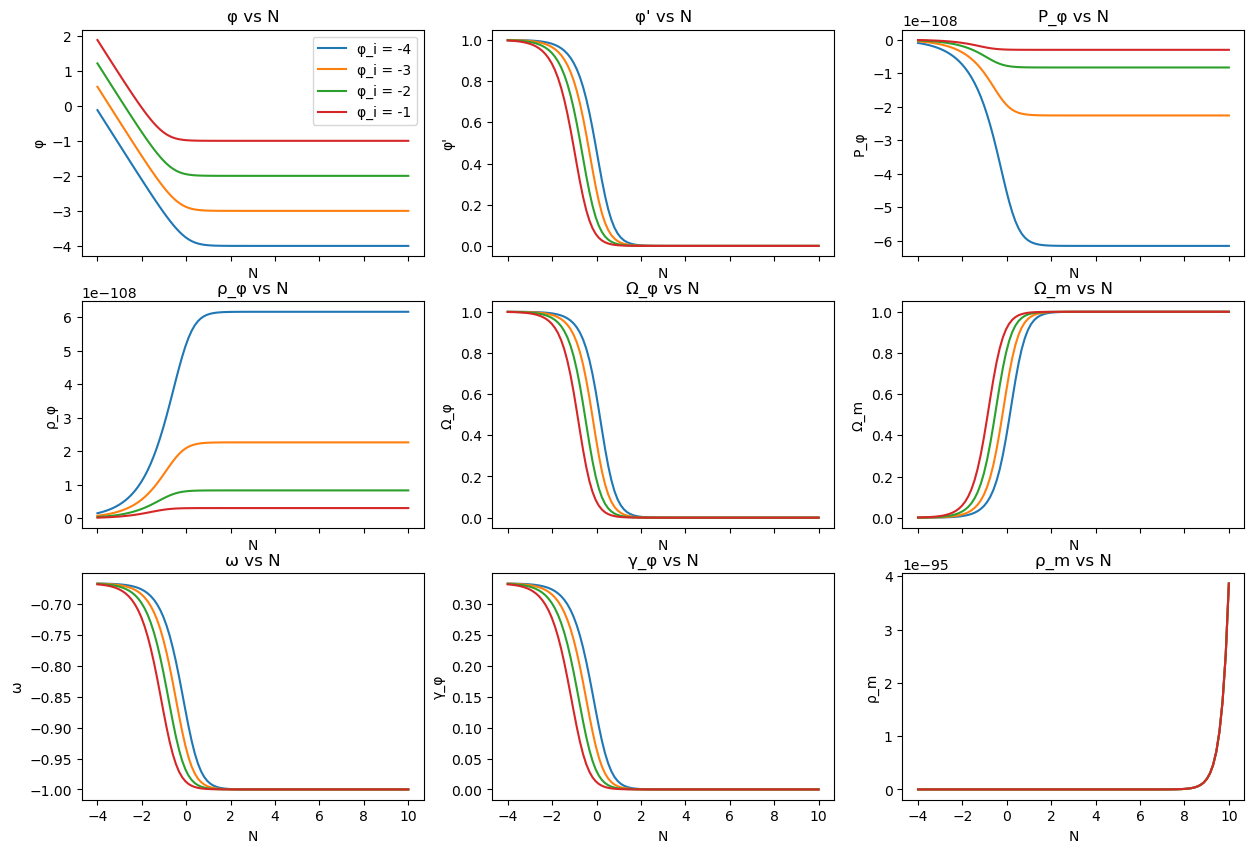

In [23]:
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)

for i in range(-4,0,1):
    solQ = odeint(CoupledCopelandKG,[i,0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(solQ[:,0],solQ[:,1],Nrange)

    # Use Subplots to observe each parameter over all N for a different intial value of φ
    axs[0,0].plot(-Nrange,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "N",title=r"φ vs N")
    axs[0,0].legend()

    axs[0,1].plot(-Nrange,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "N",title=r"φ' vs N")
    #axs[0,1].legend()

    axs[0,2].plot(-Nrange,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "N",title=r"P_φ vs N")
    #axs[0,2].legend()

    axs[1,0].plot(-Nrange,rho,label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "N",title=r"ρ_φ vs N")
    #axs[1,0].legend()

    axs[1,1].plot(-Nrange,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "N",title=r"Ω_φ vs N")
    #axs[1,1].legend()

    axs[1,2].plot(-Nrange,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "N",title=r"Ω_m vs N")
    #axs[1,2].legend()

    axs[2,0].plot(-Nrange,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "N",title=r"ω vs N")
    #axs[2,0].legend()

    axs[2,1].plot(-Nrange,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "N",title=r"γ_φ vs N")
    #axs[2,1].legend()

    axs[2,2].plot(-Nrange,rho_m,label=r"φ_i = {}".format(i))
    axs[2,2].set(ylabel = r"ρ_m", xlabel = "N",title=r"ρ_m vs N")
    #axs[2,1].legend()
    

#axs[0,0].set_xscale('log')
#axs[0,0].set_yscale('log')

#def multipleQ(Q,N):
#axs[0,0].ylabel()
    #axs[0,0].xlabel()    

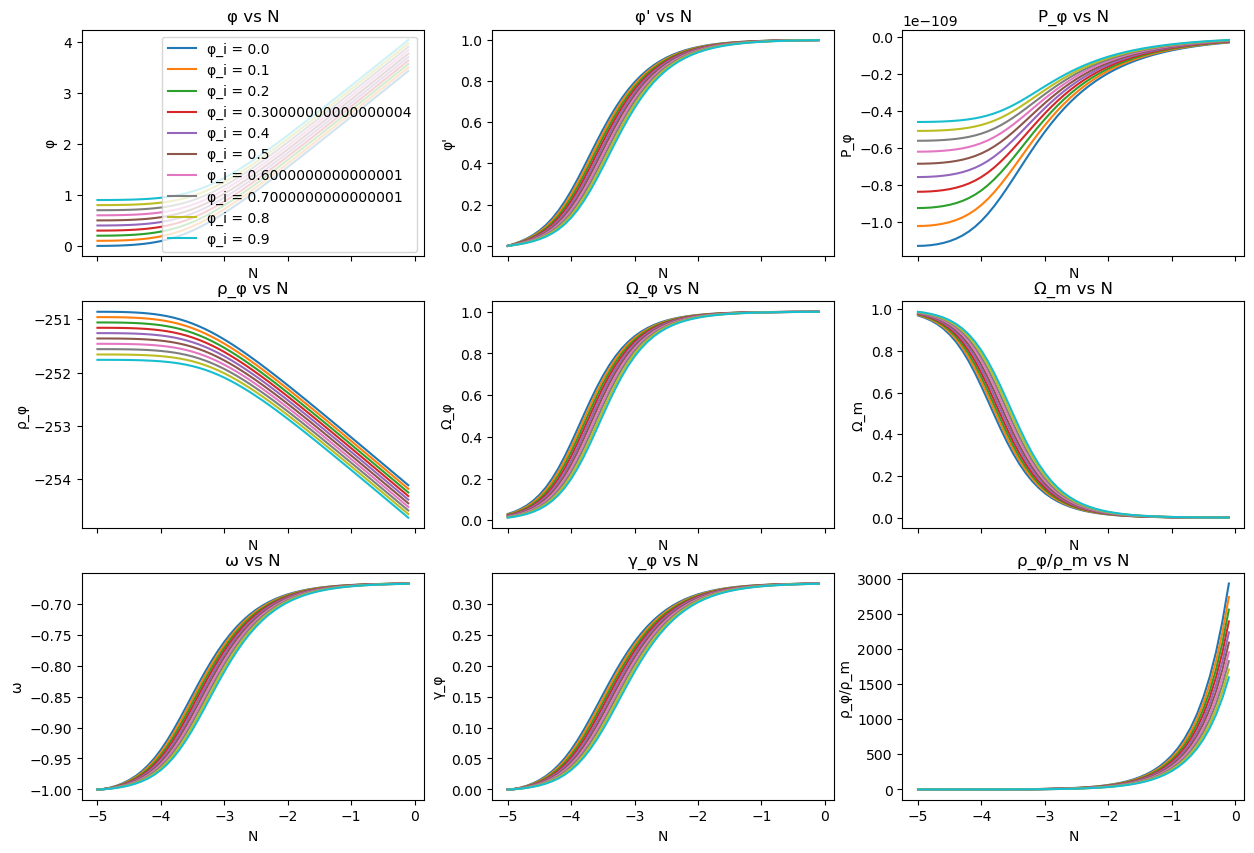

In [24]:
Nrange = np.arange(-5,0,.1)
Ni = Nrange[0]
fig, axs = plt.subplots(3,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i):
    #axs[0,0].set_xscale('log')
        
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"φ_i = {}".format(i))
    axs[0,0].set(ylabel = r"φ", xlabel = "{}".format(label),title=r"φ vs {}".format(label))
    if label == "z+1":
        axs[0,0].xaxis.set_inverted(True)
    axs[0,0].legend()
    
    axs[0,1].plot(x,solQ[:,1],label=r"φ_i = {}".format(i))
    axs[0,1].set(ylabel = r"φ'", xlabel = "{}".format(label),title=r"φ' vs {}".format(label))
    #axs[0,1].legend()
    
    axs[0,2].plot(x,P,label=r"φ_i = {}".format(i))
    axs[0,2].set(ylabel = r"P_φ", xlabel = "{}".format(label),title=r"P_φ vs {}".format(label))
    #axs[0,2].legend()
    
    axs[1,0].plot(x,log(rho),label=r"φ_i = {}".format(i))
    axs[1,0].set(ylabel = r"ρ_φ", xlabel = "{}".format(label),title=r"ρ_φ vs {}".format(label))
    #axs[1,0].legend()
    
    axs[1,1].plot(x,O_Q,label=r"φ_i = {}".format(i))
    axs[1,1].set(ylabel = r"Ω_φ", xlabel = "{}".format(label),title=r"Ω_φ vs {}".format(label))
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"φ_i = {}".format(i))
    axs[1,2].set(ylabel = r"Ω_m", xlabel = "{}".format(label),title=r"Ω_m vs {}".format(label))
    #axs[1,2].legend()

    axs[2,0].plot(x,w,label=r"φ_i = {}".format(i))
    axs[2,0].set(ylabel = r"ω", xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    #axs[2,0].legend()

    axs[2,1].plot(x,Y_Q,label=r"φ_i = {}".format(i))
    axs[2,1].set(ylabel = r"γ_φ", xlabel = "{}".format(label),title=r"γ_φ vs {}".format(label))
    #axs[2,1].legend()

    axs[2,2].plot(x,rho/rho_m,label=r"φ_i = {}".format(i))
    axs[2,2].set(ylabel = r"ρ_φ/ρ_m", xlabel = "{}".format(label),title=r"ρ_φ/ρ_m vs {}".format(label))
    
Q_values = np.arange(0,1,.1)
for i in Q_values:
    Ni = Nrange[0]
    solQ = odeint(CoupledCopelandKG,[i,0],t=Nrange)
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    Z = z+1
    xaxis(Nrange,"N",i) # Here is where you can alter whether to view graphs w.r.t to N or z+1